In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import random
import polars as pl
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim.lr_scheduler as lr_scheduler

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
DONOR = 'donor_4'
RANDOM_SEED = 24
NUM_ITEMS = 100_000

In [3]:
WORKING_PATH = Path('/group/pmc021/amunif/epi-thesis/workflow/16_Pairwise Ranking Healthy Liver/')
DATASET_PATH = WORKING_PATH / 'dataset'/ DONOR
OUTPUT_PATH  = WORKING_PATH / 'output' / DONOR

In [4]:
print(WORKING_PATH)
print(DATASET_PATH)
print(OUTPUT_PATH)

/group/pmc021/amunif/epi-thesis/workflow/16_Pairwise Ranking Healthy Liver
/group/pmc021/amunif/epi-thesis/workflow/16_Pairwise Ranking Healthy Liver/dataset/donor_4
/group/pmc021/amunif/epi-thesis/workflow/16_Pairwise Ranking Healthy Liver/output/donor_4


In [5]:
# Get the device
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [6]:
device = get_device()

Using device: cpu


In [7]:
# Set the random seed for torch, random, and np.random
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [8]:
# Load histone data
data_df = pl.read_parquet(DATASET_PATH / 'donor4_exp_histones.parquet')
data_df

gene_id,H3K9ac,H3K9ac_wc,H3K9ac_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K27ac,H3K27ac_wc,H3K27ac_len,H3K27me3,H3K27me3_wc,H3K27me3_len,value
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64
"""ENSG00000000003""","[0.0, 0.0, … 0.0]",17,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",18,100,"[0.0, 0.0, … 3.82071]",18,100,"[0.0, 0.0, … 0.0]",0,100,73.205
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.191
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",33,100,"[0.0, 0.0, … 0.0]",28,100,"[0.0, 0.0, … 0.0]",0,100,52.609
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",42,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",42,100,"[0.0, 0.0, … 0.0]",44,100,"[0.0, 0.0, … 0.0]",0,100,4.733
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.942
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071


In [9]:
# Load permutation list
permutation_lst = pl.read_parquet(DATASET_PATH / 'marker_combinations.parquet')["combination"].to_list()
permutation_lst

[['H3K4me3'],
 ['H3K9ac'],
 ['H3K9me3'],
 ['H3K27ac'],
 ['H3K27me3'],
 ['H3K4me3', 'H3K9ac'],
 ['H3K4me3', 'H3K9me3'],
 ['H3K4me3', 'H3K27ac'],
 ['H3K4me3', 'H3K27me3'],
 ['H3K9ac', 'H3K9me3'],
 ['H3K9ac', 'H3K27ac'],
 ['H3K9ac', 'H3K27me3'],
 ['H3K9me3', 'H3K27ac'],
 ['H3K9me3', 'H3K27me3'],
 ['H3K27ac', 'H3K27me3'],
 ['H3K4me3', 'H3K9ac', 'H3K9me3'],
 ['H3K4me3', 'H3K9ac', 'H3K27ac'],
 ['H3K4me3', 'H3K9ac', 'H3K27me3'],
 ['H3K4me3', 'H3K9me3', 'H3K27ac'],
 ['H3K4me3', 'H3K9me3', 'H3K27me3'],
 ['H3K4me3', 'H3K27ac', 'H3K27me3'],
 ['H3K9ac', 'H3K9me3', 'H3K27ac'],
 ['H3K9ac', 'H3K9me3', 'H3K27me3'],
 ['H3K9ac', 'H3K27ac', 'H3K27me3'],
 ['H3K9me3', 'H3K27ac', 'H3K27me3'],
 ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac'],
 ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27me3'],
 ['H3K4me3', 'H3K9ac', 'H3K27ac', 'H3K27me3'],
 ['H3K4me3', 'H3K9me3', 'H3K27ac', 'H3K27me3'],
 ['H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3'],
 ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]

In [10]:
# Split the train, test, and val
all_idx = np.arange(len(data_df))
all_idx

array([    0,     1,     2, ..., 19642, 19643, 19644], shape=(19645,))

In [11]:
# First split: 80% train, 20% temp
train_idx, temp_idx = train_test_split (
    all_idx,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True
)

In [12]:
# Second split: 50% val, 50% test
val_idx, test_idx = train_test_split (
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_SEED,
    shuffle=True
)

In [13]:
print(f"Train : {len(train_idx):>6}  ({len(train_idx)/len(data_df)*100:.1f}%)")
print(f"Val   : {len(val_idx):>6}  ({len(val_idx)/len(data_df)*100:.1f}%)")
print(f"Test  : {len(test_idx):>6}  ({len(test_idx)/len(data_df)*100:.1f}%)")

Train :  15716  (80.0%)
Val   :   1964  (10.0%)
Test  :   1965  (10.0%)


In [14]:
# Sanity check – no overlap between partitions
assert len(set(train_idx) & set(val_idx))  == 0, "Train/Val overlap!"
assert len(set(train_idx) & set(test_idx)) == 0, "Train/Test overlap!"
assert len(set(val_idx)   & set(test_idx)) == 0, "Val/Test overlap!"
print("No overlap between partitions")

No overlap between partitions


In [15]:
# Generate pairs with labels
def generate_pairs_with_labels(data_df, indexes, num_pairs=100_000, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(indexes, size=(num_pairs, 2), replace=True)
    
    val_1 = data_df["value"][idx[:, 0]].to_numpy()
    val_2 = data_df["value"][idx[:, 1]].to_numpy()
    labels = (val_1 > val_2).astype(int)

    return np.column_stack([idx[:, 0], idx[:, 1], labels])

In [16]:
# Get label distributions
def get_label_distribution(pairs):
    unique, counts = np.unique(pairs[:, 2], return_counts=True)
    total = len(pairs)
    for label, count in zip(unique, counts):
        print(f"Label {label}: {count:>6} ({count/total*100:.1f}%)")

In [17]:
train_pairs = generate_pairs_with_labels(data_df, train_idx, int(0.8 * NUM_ITEMS), RANDOM_SEED)
val_pairs = generate_pairs_with_labels(data_df, val_idx, int(0.1 * NUM_ITEMS), RANDOM_SEED)
test_pairs = generate_pairs_with_labels(data_df, test_idx, int(0.1 * NUM_ITEMS), RANDOM_SEED)

In [18]:
print("Train label distributions: ")
get_label_distribution(train_pairs)

print("Validation label distributions: ")
get_label_distribution(val_pairs)

print("Test label distributions: ")
get_label_distribution(test_pairs)

Train label distributions: 
Label 0:  40949 (51.2%)
Label 1:  39051 (48.8%)
Validation label distributions: 
Label 0:   5169 (51.7%)
Label 1:   4831 (48.3%)
Test label distributions: 
Label 0:   5148 (51.5%)
Label 1:   4852 (48.5%)


In [ ]:
# # Binary Classifier class
# class BinaryClassifierDropOutL1L2_v1(nn.Module):
#     def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2, l1_lambda=0.001, l2_lambda=0.001):
#         super(BinaryClassifierDropOutL1L2_v1, self).__init__()

#         self.network = nn.Sequential(
#             nn.Linear(input_size, hidden1_size),
#             # nn.ReLU(),
#             nn.LeakyReLU(0.1),
#             nn.Dropout(p=dropout_rate),
#             nn.Linear(hidden1_size, hidden2_size),
#             # nn.ReLU(),
#             nn.LeakyReLU(0.1),
#             nn.Dropout(p=dropout_rate),
#             nn.Linear(hidden2_size, output_size),
#             nn.Sigmoid()
#         )

#         self.l1_lambda = l1_lambda
#         self.l2_lambda = l2_lambda

#     def forward(self, x):
#         # x = x.squeeze(1)
#         outputs = self.network(x)
#         l1_reg = torch.tensor(0., requires_grad=True)
#         l2_reg = torch.tensor(0., requires_grad=True)

#         for name, param in self.named_parameters():
#             if 'weight' in name:
#                 l1_reg = l1_reg + torch.linalg.norm(param, 1)
#                 l2_reg = l2_reg + torch.linalg.norm(param, 2)

#         return outputs, self.l1_lambda * l1_reg, self.l2_lambda * l2_reg

#     def predict(self, x):
#         with torch.no_grad():
#             outputs, _, _ = self.forward(x)
#             return (outputs >= 0.5).long()

In [20]:
# Binary Classifier using DirectRanker-style with antisymmetric twin-subnet model
class BinaryClassifierDropOutL1L2(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1,
                 dropout_rate=0.2, l1_lambda=0.001, l2_lambda=0.001):
        super(BinaryClassifierDropOutL1L2, self).__init__()
 
        # Single-gene feature size (half the concatenated input)
        self.gene_input_size = input_size // 2
 
        # Shared subnet: processes one gene's features into a scalar score
        self.subnet = nn.Sequential(
            nn.Linear(self.gene_input_size, hidden1_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size)
            # Remove the sigmoid, this will be applied after subtraction
        )
 
        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda
 
    def forward(self, x):
        # Split concatenated pair [gene1 | gene2] into individual feature vectors
        gene1 = x[:, :self.gene_input_size]
        gene2 = x[:, self.gene_input_size:]
 
        # Shared subnet processes each gene independently (weight-tied)
        score1 = self.subnet(gene1)  # (batch, 1)
        score2 = self.subnet(gene2)  # (batch, 1)
 
        # Antisymmetric output: sigmoid(score1 - score2)
        # Swapping gene1/gene2 gives sigmoid(score2 - score1) = 1 - output
        outputs = torch.sigmoid(score1 - score2)
 
        # L1 / L2 regularisation on subnet weights
        l1_reg = torch.tensor(0., requires_grad=True)
        l2_reg = torch.tensor(0., requires_grad=True)
        for name, param in self.named_parameters():
            if 'weight' in name:
                l1_reg = l1_reg + torch.linalg.norm(param, 1)
                l2_reg = l2_reg + torch.linalg.norm(param, 2)
 
        return outputs, self.l1_lambda * l1_reg, self.l2_lambda * l2_reg
 
    def predict(self, x):
        with torch.no_grad():
            outputs, _, _ = self.forward(x)
            return (outputs >= 0.5).long()

In [21]:
class LiverDataset(Dataset):
    def __init__(self, total_samples, features, pairs):
        self.total_samples = total_samples
        self.features = features        # numpy array: [gene_id, histone]
        self.pairs = pairs  # numpy array: [gene_id1, gene_id2, label]

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        pair = self.pairs[idx % len(self.pairs)]
        
        gene_id1, gene_id2, label = pair[0], pair[1], pair[2]
        
        feature_1 = self.features[gene_id1, 1]
        feature_2 = self.features[gene_id2, 1]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        y = int(label)
        
        return feature, y

In [22]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, ITEM_NAME, num_items, file_name):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot for training and validation Loss
    ax1.plot(epochs, train_losses, 'blue', label='Training Loss')
    ax1.plot(epochs, val_losses, 'orange', label='Validation Loss')
    ax1.set_title(f'Training and Validation Loss\n{ITEM_NAME}', fontsize=10)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_ylim(0.4, 0.8)
    ax1.legend()
    ax1.grid(True)
    
    # Plot for training and validation Accuracy
    ax2.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    ax2.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    ax2.set_title(f'Training and Validation Accuracy\n{ITEM_NAME}', fontsize=10)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(50, 90)
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(file_name, bbox_inches='tight')

In [23]:
# Define file numbering based on the index
def format_file_number(number):
    if number < 10:
        return f"00{number}"
    elif number < 100:
        return f"0{number}"
    else:
        return str(number)

In [26]:
# Get the start and end batch
START = 30
END = 31

030-H3K4me3-H3K9ac-H3K9me3-H3K27ac-H3K27me3
Train label distributions: 
Label 0:    400 (50.0%)
Label 1:    400 (50.0%)
Validation label distributions: 
Label 0:     51 (51.0%)
Label 1:     49 (49.0%)
Test label distributions: 
Label 0:     48 (48.0%)
Label 1:     52 (52.0%)
Epoch [1/100] - [TRAIN] Loss: 0.7365, Accuracy: 46.25%, AUC: 0.46 [VAL] Loss: 0.7124, Accuracy: 57.00%, Precision: 0.56, Recall: 0.61, F1-Score: 0.58, AUC: 0.57
Epoch [2/100] - [TRAIN] Loss: 0.7047, Accuracy: 55.38%, AUC: 0.55 [VAL] Loss: 0.6568, Accuracy: 78.00%, Precision: 0.78, Recall: 0.78, F1-Score: 0.78, AUC: 0.78
Epoch [3/100] - [TRAIN] Loss: 0.6574, Accuracy: 65.25%, AUC: 0.65 [VAL] Loss: 0.6172, Accuracy: 79.00%, Precision: 0.79, Recall: 0.78, F1-Score: 0.78, AUC: 0.79
Epoch [4/100] - [TRAIN] Loss: 0.6460, Accuracy: 68.75%, AUC: 0.69 [VAL] Loss: 0.5903, Accuracy: 81.00%, Precision: 0.80, Recall: 0.82, F1-Score: 0.81, AUC: 0.81
Epoch [5/100] - [TRAIN] Loss: 0.6176, Accuracy: 72.12%, AUC: 0.72 [VAL] Loss: 0.

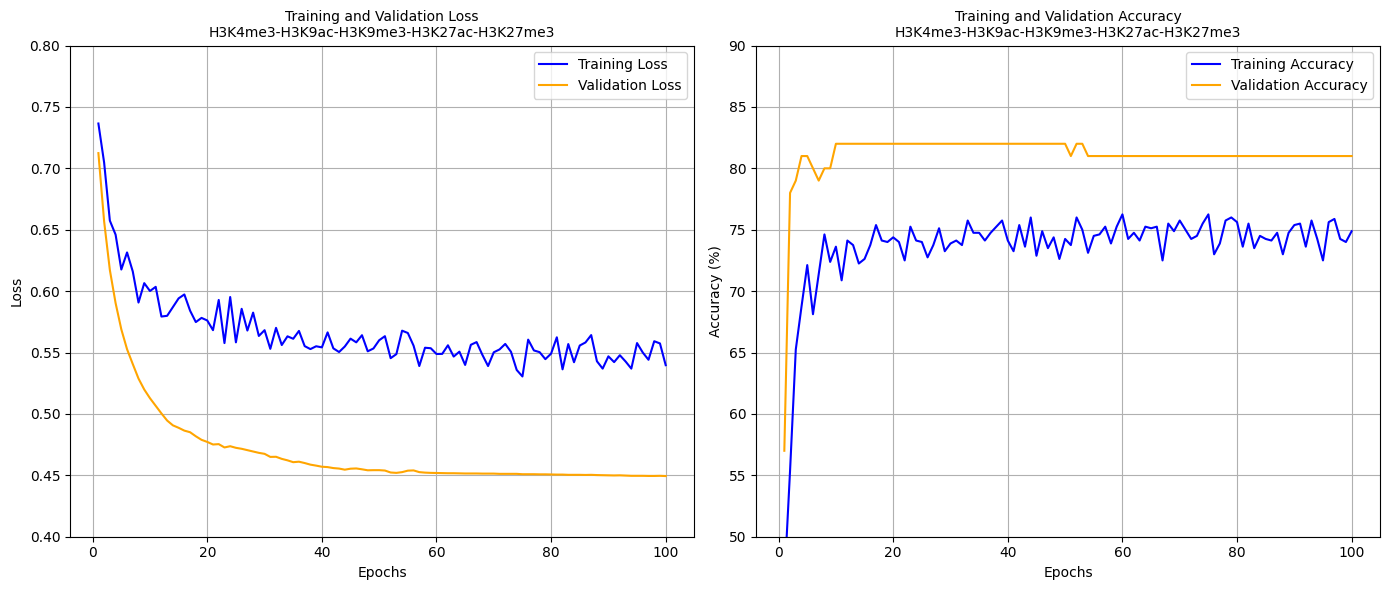

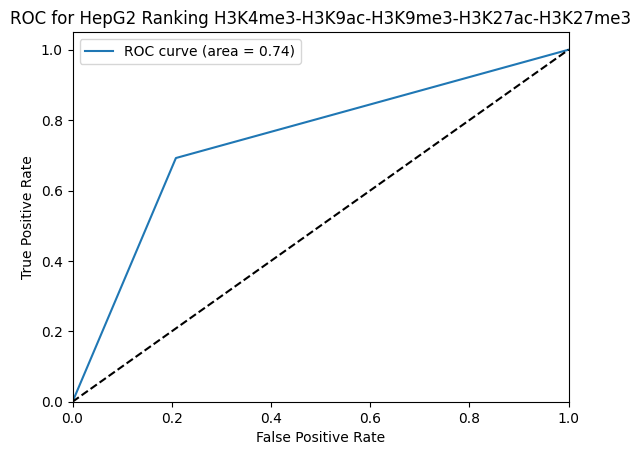

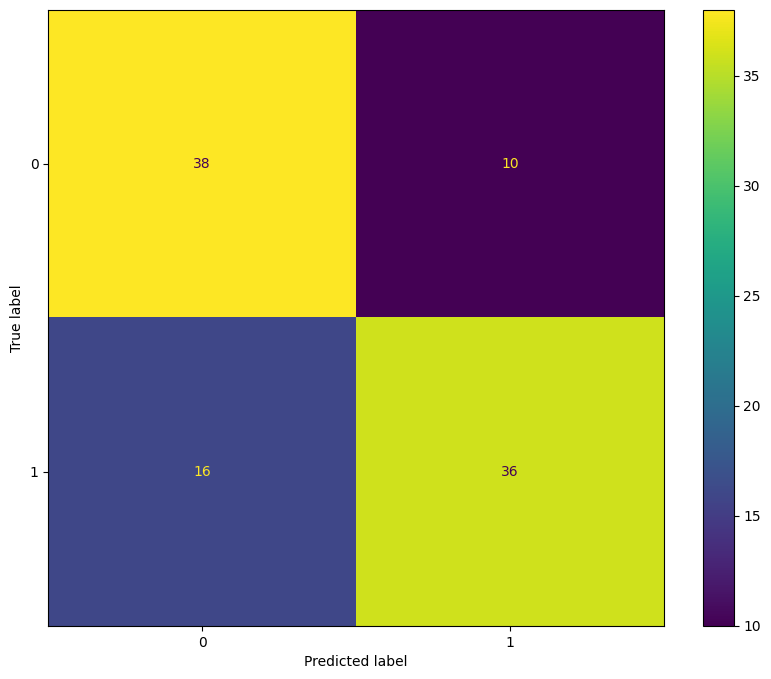

In [29]:
for number in range(START, END):
    # Building the dataframe based on histone markers
    item = permutation_lst[number]
    ITEM_NAME = '-'.join(item)
    FILE_NUMBER = format_file_number(number)
    print(f"{FILE_NUMBER}-{ITEM_NAME}")

    data_df = data_df.with_columns(histone=pl.concat_list(item))
    X = data_df["gene_id", "histone"]
    X_np = X.to_numpy()

    # Setup the experiment variable
    NUM_ITEMS = 1_000
    BATCH_SIZE = 32
    INPUT_SIZE = len(X_np[0][1]) * 2 # Two histone marker data from two gene IDs
    NUM_EPOCHS = 100
    START_EPOCH = 0
    DROPOUT_RATE = 0.3
    L1_lambda = 0.005
    L2_lambda = 0.001
    EARLY_STOPPING_PATIENCE = 10

    # Generate train, val, and test pairs
    train_pairs = generate_pairs_with_labels(data_df, train_idx, int(0.8 * NUM_ITEMS), RANDOM_SEED)
    val_pairs = generate_pairs_with_labels(data_df, val_idx, int(0.1 * NUM_ITEMS), RANDOM_SEED)
    test_pairs = generate_pairs_with_labels(data_df, test_idx, int(0.1 * NUM_ITEMS), RANDOM_SEED)
    print("Train label distributions: ")
    get_label_distribution(train_pairs)
    print("Validation label distributions: ")
    get_label_distribution(val_pairs)
    print("Test label distributions: ")
    get_label_distribution(test_pairs)
    

    # Setup the data
    train_dataset = LiverDataset(int(0.8 * NUM_ITEMS), X_np, train_pairs)
    val_dataset = LiverDataset(int(0.1 * NUM_ITEMS), X_np, val_pairs)
    test_dataset = LiverDataset(int(0.1 * NUM_ITEMS), X_np, test_pairs)

    # Define the dataloader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    # Define classifier model
    model = BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

    # Define loss function for binary classification
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss

    # Training loop example
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

    # Define learning rate scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

    # Arrays for saving the performance metric
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_aucs, val_aucs = [], []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    # Early stopping state
    best_val_loss   = float('inf')
    early_stop_counter = 0
    best_model_weights = None

    # Setup filename
    IMAGE_FILE       = OUTPUT_PATH / 'img' / 'train' / f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-ranking.png"
    TEST_FILE        = OUTPUT_PATH / 'test' /          f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-test-results.txt"
    TRAINING_FILE    = OUTPUT_PATH / 'train' /         f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-train-validation-metrics.csv"
    TEST_RESULT_FILE = OUTPUT_PATH / 'test' /          f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-test-metrics.csv"
    ROC_FILE         = OUTPUT_PATH / 'img' / 'roc' /   f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-roc.png"
    CM_FILE          = OUTPUT_PATH / 'img' / 'cm' /    f"{FILE_NUMBER}-{ITEM_NAME}-seed{RANDOM_SEED}-cm.png"

    # Training Phase
    # Training loop
    for epoch in range(START_EPOCH, NUM_EPOCHS):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0
        train_true_labels = []
        train_predicted_labels = []

        # Training phase
        for X_batch, y_batch in train_loader:
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            predictions = (outputs.squeeze(1) >= 0.5).long()

            train_loss += loss.item()
            train_correct += (predictions == y_batch.to(device)).sum().item()
            train_total += y_batch.size(0)
            
            train_true_labels.extend(y_batch.cpu().numpy())
            train_predicted_labels.extend(predictions.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

        train_losses.append(round(avg_train_loss, 4))
        train_accuracies.append(round(train_accuracy, 2))
        train_aucs.append(round(train_auc_score, 2))

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_metric = 0
        val_true_labels = []
        val_predicted_labels = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
                
                predictions = (outputs.squeeze(1) >= 0.5).long()
                
                val_loss += loss.item()
                val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
                val_total += y_batch.size(0)
                val_true_labels.extend(y_batch.cpu().numpy())
                val_predicted_labels.extend(predictions.cpu().numpy())
                
            avg_val_loss = val_loss / len(val_loader)
            val_accuracy = 100 * val_correct / val_total
            val_metric = val_correct / len(val_loader)

            # Calculate precision, recall, and F1-score
            precision, recall, f1_score, _ = precision_recall_fscore_support(
                val_true_labels, 
                val_predicted_labels, 
                average='binary'  # Use macro average for multi-class classification
            )

            val_true_labels = np.array(val_true_labels)
            val_predicted_labels = np.array(val_predicted_labels)
            val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

            val_losses.append(round(avg_val_loss, 4))
            val_accuracies.append(round(val_accuracy, 2))
            val_aucs.append(round(val_auc_score, 2))
            val_precisions.append(round(precision, 2))
            val_recalls.append(round(recall, 2))
            val_f1_scores.append(round(f1_score, 2))

        # Adjust learning rate
        scheduler.step(val_loss)

        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
            f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
            f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
            f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
            f'AUC: {val_auc_score:.2f}')
        
        # ── Early stopping check ──────────────────────────────────────────
        if avg_val_loss < best_val_loss:
            best_val_loss      = avg_val_loss
            early_stop_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            early_stop_counter += 1
            if early_stop_counter >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stopping at epoch {epoch+1} '
                        f'(no val_loss improvement for {EARLY_STOPPING_PATIENCE} epochs)')
                break

    # Restore the best weights before evaluations
    model.load_state_dict(best_model_weights)

    # Plot training and validation metric
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, ITEM_NAME, NUM_ITEMS, IMAGE_FILE)

    # Predict on test set
    test_predictions = []
    test_true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            test_true_labels.extend(y_batch.cpu().numpy())
            test_predictions.extend(predictions.cpu().numpy())

    # Evaluation metrics
    # Precision, Recall, F1-Score
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_true_labels, 
        test_predictions, 
        average='binary'  # Use 'macro' for multi-class
    )

    test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
    test_auc_score = roc_auc_score(test_true_labels, test_predictions)
    cr = classification_report(test_true_labels, test_predictions)
    cm = confusion_matrix(test_true_labels, test_predictions)

    test_output = (
            f"Seed: {RANDOM_SEED}\n"
            f"Accuracy Score on test set: {test_acc_score:.2f} %\n"
            f"AUC Score on test set: {test_auc_score:.2f}\n"
            f"Precision: {precision:.4f}\n"
            f"Recall: {recall:.4f}\n"
            f"F1-Score: {f1_score:.4f}\n\n"
            f"Detailed Classification Report:\n{cr}\n\n"
            f"Confusion Matrix:\n{cm}\n"
        )
    print(test_output)

    # Save the test output to text file
    with open(TEST_FILE, 'w', newline = '') as text_file:
        text_file.write(test_output)

    # Training metrics
    experiment_results = {
        'seed'          : RANDOM_SEED,
        'train_loss'    : train_losses,
        'train_accuracy': train_accuracies,
        'train_auc'     : train_aucs,
        'val_loss'      : val_losses,
        'val_accuracy'  : val_accuracies,
        'val_auc'       : val_aucs
    }

    experiment_pl = pl.DataFrame(experiment_results)
    experiment_pl.write_csv(TRAINING_FILE)

    # Get the average for each column
    experiment_mean = experiment_pl.mean()
    experiment_mean

    # Test output
    test_results = {
        'seed'               : RANDOM_SEED,
        'histone_marker'     : ITEM_NAME,
        'train_loss_avg'     : round(experiment_mean["train_loss"][0], 4),
        'train_accuracy_avg' : round(experiment_mean["train_accuracy"][0], 4),
        'train_auc_avg'      : round(experiment_mean["train_auc"][0], 4),
        'val_loss_avg'       : round(experiment_mean["val_loss"][0], 4),
        'val_accuracy_avg'   : round(experiment_mean["val_accuracy"][0], 4),
        'val_auc_avg'        : round(experiment_mean["val_auc"][0], 4),
        'test_accuracy'      : round(test_acc_score, 4),
        'test_auc'           : round(test_auc_score, 4)
    }

    test_pl = pl.DataFrame(test_results)
    test_pl.write_csv(TEST_RESULT_FILE)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure()  
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for HepG2 Ranking {ITEM_NAME}')
    plt.legend()
    plt.savefig(ROC_FILE)
    # plt.show()

    # Plot the confusion matrix
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(10, 8))
    cm_display.plot(ax=ax)
    plt.savefig(CM_FILE)

print("Batch FINISHED!!!")